In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Set plotting style for professional, clean visuals
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# Ensure the plots directory exists
os.makedirs('../plots', exist_ok=True)

# Load the raw dataset (we analyze raw data, not scaled data, for human readability)
df = pd.read_csv('../data/fertilizer_recommendation.csv')

print("Data loaded successfully for EDA.")

Data loaded successfully for EDA.


In [3]:
print("--- Dataset Shape ---")
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}\n")

print("--- Data Types ---")
print(df.dtypes, "\n")

print("--- Summary Statistics (Numerical) ---")
display(df.describe())

# Expected Observation:
# Look at the 'min' and 'max' rows in the summary statistics. 
# Are there impossible values? (e.g., negative Rainfall or Soil_pH > 14).

--- Dataset Shape ---
Rows: 10000, Columns: 20

--- Data Types ---
Soil_Type                       object
Soil_pH                        float64
Soil_Moisture                  float64
Organic_Carbon                 float64
Electrical_Conductivity        float64
Nitrogen_Level                   int64
Phosphorus_Level                 int64
Potassium_Level                  int64
Temperature                    float64
Humidity                       float64
Rainfall                       float64
Crop_Type                       object
Crop_Growth_Stage               object
Season                          object
Irrigation_Type                 object
Previous_Crop                   object
Region                          object
Fertilizer_Used_Last_Season    float64
Yield_Last_Season              float64
Recommended_Fertilizer          object
dtype: object 

--- Summary Statistics (Numerical) ---


,Soil_pH,Soil_Moisture,Organic_Carbon,Electrical_Conductivity,Nitrogen_Level,Phosphorus_Level,Potassium_Level,Temperature,Humidity,Rainfall,Fertilizer_Used_Last_Season,Yield_Last_Season
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,6.485728,35.411531,0.844731,1.543156,88.995000,48.965100,64.147000,25.058906,60.093727,1588.085798,176.165508,4.531666
std,1.152964,14.413002,0.372406,0.839514,40.336674,23.195588,31.867211,8.601550,17.386120,810.992404,72.235790,2.013522
min,4.500000,10.000000,0.200000,0.100000,20.000000,10.000000,10.000000,10.000000,30.010000,200.080000,50.010000,1.000000
25%,5.490000,23.030000,0.520000,0.820000,54.000000,29.000000,37.000000,17.580000,44.925000,874.780000,113.175000,2.780000
50%,6.460000,35.645000,0.850000,1.530000,89.000000,49.000000,64.000000,25.085000,60.345000,1594.295000,176.835000,4.550000
75%,7.490000,47.662500,1.160000,2.270000,124.000000,69.000000,92.000000,32.502500,75.420000,2283.782500,239.232500,6.260000
max,8.500000,60.000000,1.500000,3.000000,159.000000,89.000000,119.000000,40.000000,89.990000,2999.980000,300.000000,8.000000


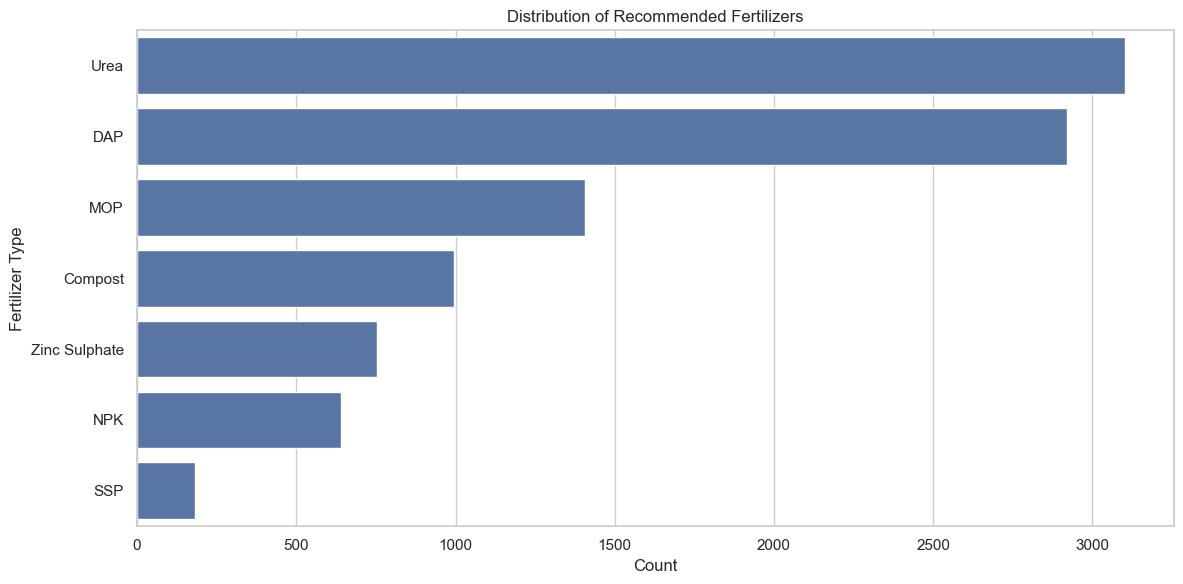

Class Counts:
Recommended_Fertilizer
Urea             3101
DAP              2920
MOP              1408
Compost           996
Zinc Sulphate     752
NPK               641
SSP               182
Name: count, dtype: int64


In [4]:
plt.figure(figsize=(12, 6))
sns.countplot(data=df, y='Recommended_Fertilizer', order=df['Recommended_Fertilizer'].value_counts().index)
plt.title('Distribution of Recommended Fertilizers')
plt.xlabel('Count')
plt.ylabel('Fertilizer Type')
plt.tight_layout()

# Save the plot
plt.savefig('../plots/01_class_distribution.png')
plt.show()

print("Class Counts:")
print(df['Recommended_Fertilizer'].value_counts())

# Expected Observation:
# If the counts are roughly equal, we can proceed safely.
# If highly imbalanced, we would need to note this to use techniques like SMOTE or class weighting later.

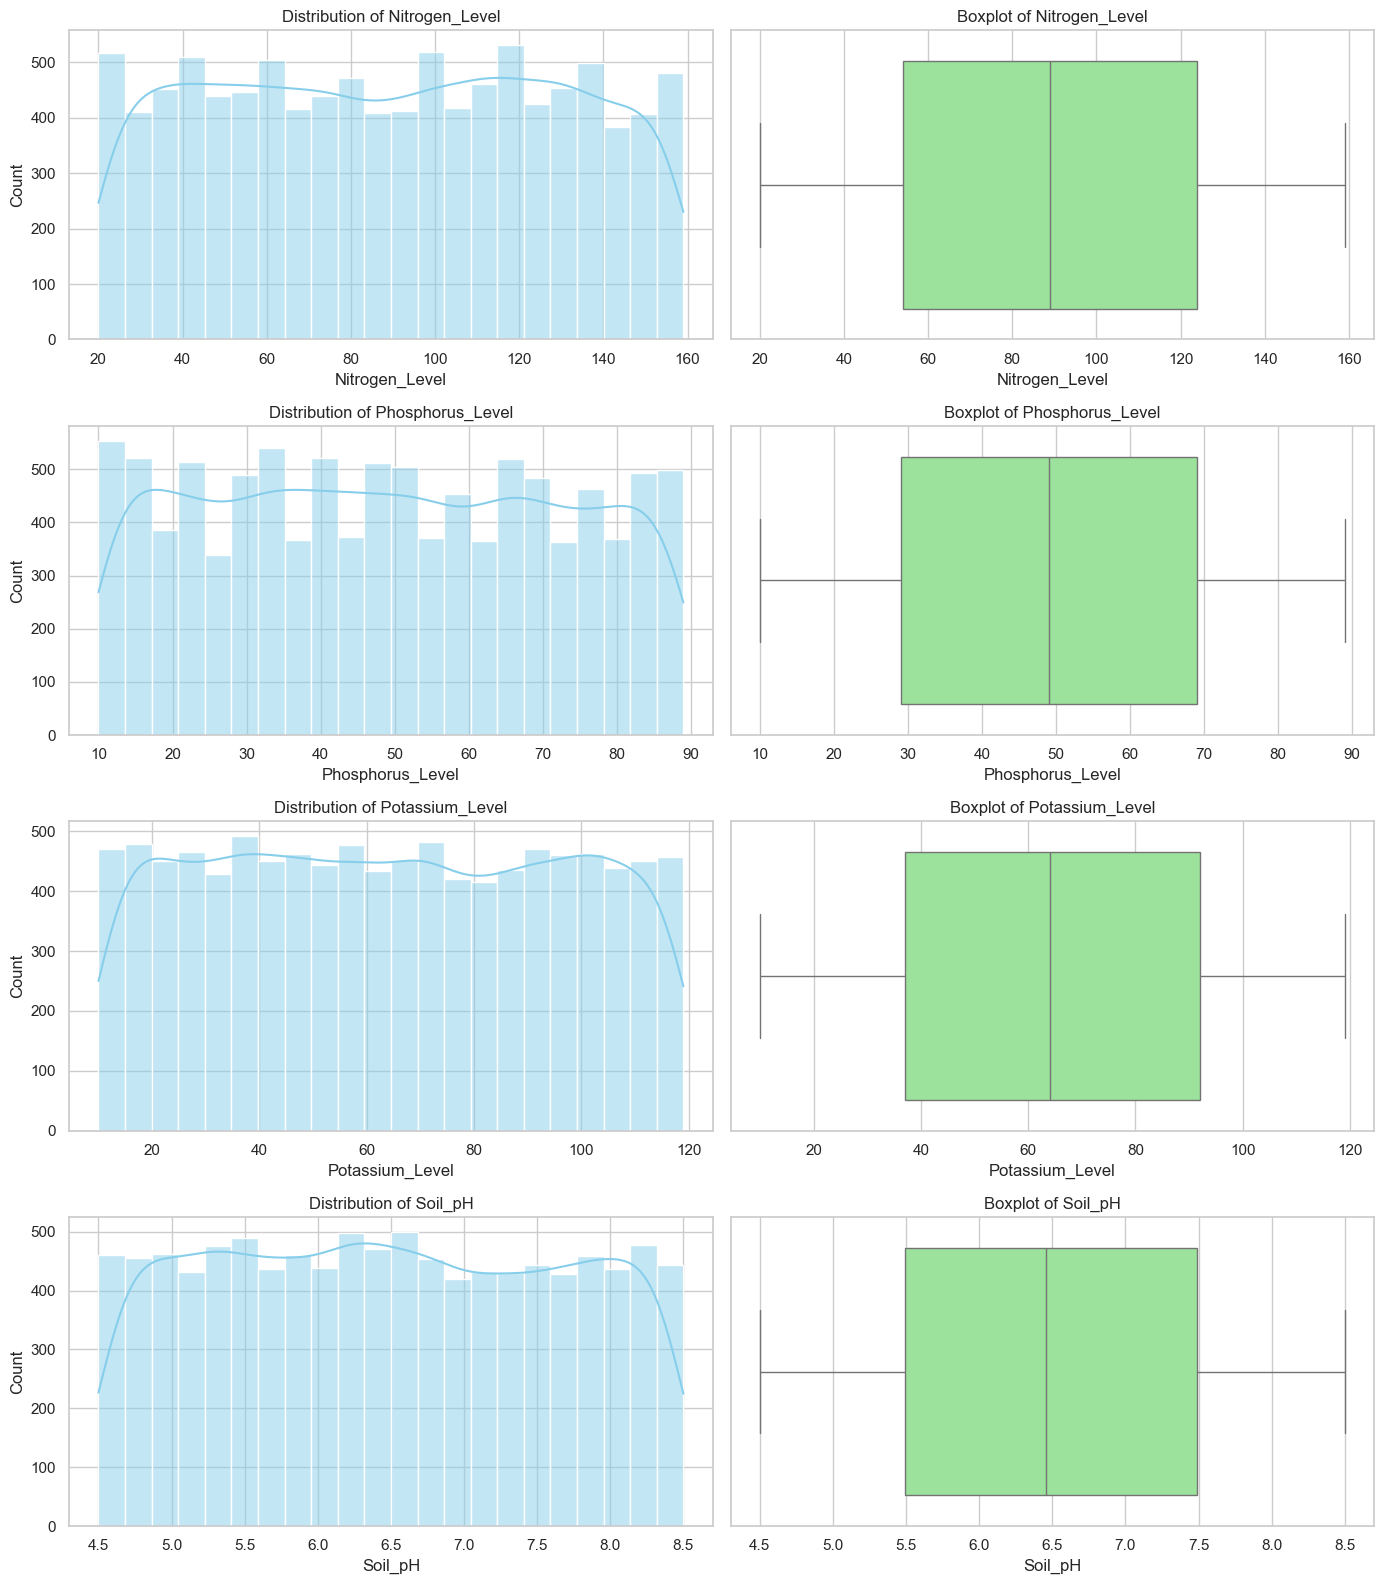

In [5]:
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

# Plot histograms and boxplots for a few critical features
critical_features = ['Nitrogen_Level', 'Phosphorus_Level', 'Potassium_Level', 'Soil_pH']

fig, axes = plt.subplots(len(critical_features), 2, figsize=(14, 4 * len(critical_features)))

for i, col in enumerate(critical_features):
    # Histogram
    sns.histplot(df[col], kde=True, ax=axes[i, 0], color='skyblue')
    axes[i, 0].set_title(f'Distribution of {col}')
    
    # Boxplot
    sns.boxplot(x=df[col], ax=axes[i, 1], color='lightgreen')
    axes[i, 1].set_title(f'Boxplot of {col}')

plt.tight_layout()
plt.savefig('../plots/02_numerical_distributions_outliers.png')
plt.show()

# Expected Observation:
# Look at the boxplots (the dots outside the whiskers). 
# Extreme high values in NPK are prime candidates for triggering our sustainability warnings later.

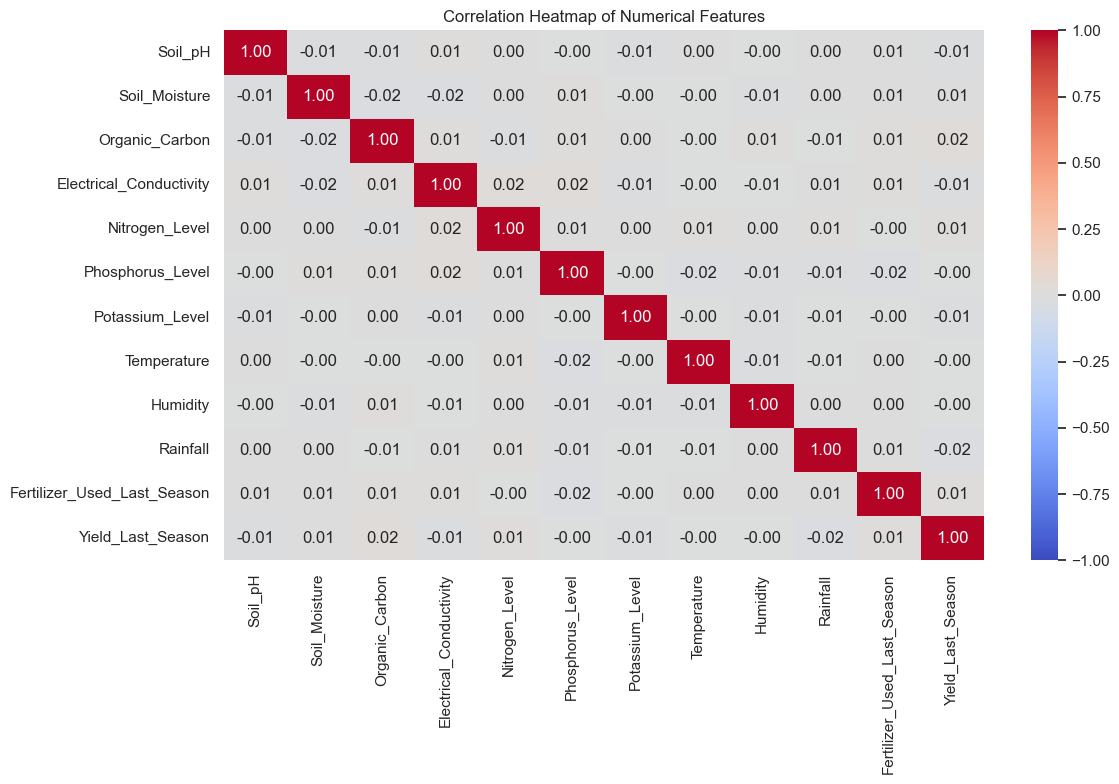

In [6]:
plt.figure(figsize=(12, 8))
# Calculate correlation matrix for numerical features
corr_matrix = df[numerical_cols].corr()

# Create a heatmap
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation Heatmap of Numerical Features')
plt.tight_layout()

plt.savefig('../plots/03_correlation_heatmap.png')
plt.show()

# Expected Observation:
# Does Humidity correlate heavily with Rainfall? Does Soil_Moisture correlate with Temperature?
# If two features correlate > 0.90, they provide redundant information.